# Testing file 1

## Stellar light curves from the Keplar Mission


In [31]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
from pandas.conftest import ignore_doctest_warning

# --- AUTOMATIC FIGURE DIRECTORY HANDLING ---
os.makedirs("figures", exist_ok=True)

# --- GLOBAL PLOTTING STYLE UPGRADE ---
plt.style.use('dark_background')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'font.size': 12,
    'axes.labelsize': 13,
    'axes.titlesize': 14,
    'legend.fontsize': 10,
    'lines.linewidth': 1.5,
    'scatter.marker': 'o'
})
print("Publication plotting style and /figures/ directory initialized.")

# Load data (handle NA safely) and save memory using float32
flux1 = np.genfromtxt("datasets/Kepler1.dat", dtype=np.float32, missing_values="NA", filling_values=np.nan)
flux2 = np.genfromtxt("datasets/Kepler2.dat", dtype=np.float32, missing_values="NA", filling_values=np.nan)

# Count missing values
n_missing_flux1 = np.isnan(flux1).sum()
n_missing_flux2 = np.isnan(flux2).sum()
n_total_flux1 = len(flux1)
n_total_flux2 = len(flux2)
print(f"Kepler1: {n_missing_flux1}/{n_total_flux1} ({100 * n_missing_flux1 / n_total_flux1:.2f}% missing)")
print(f"kepler2: {n_missing_flux2}/{n_total_flux2} ({100 * n_missing_flux2 / n_total_flux2:.2f}% missing)")

Publication plotting style and /figures/ directory initialized.
Kepler1: 11337/71427 (15.87% missing)
kepler2: 20598/71427 (28.84% missing)


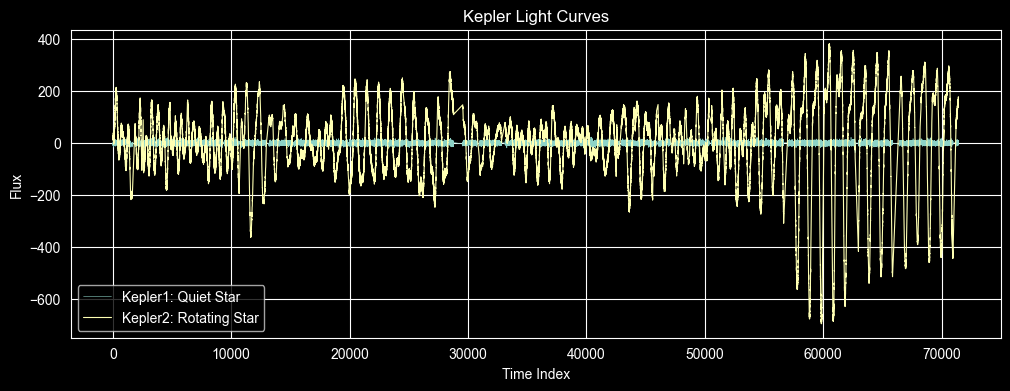

In [7]:
# Masked plots to ignore NaNs
t1 = np.arange(len(flux1))
t2 = np.arange(len(flux2))

plt.figure(figsize=(12, 4))
plt.plot(t1[~np.isnan(flux1)], flux1[~np.isnan(flux1)], lw=0.4, label='Kepler1: Quiet Star')
plt.plot(t2[~np.isnan(flux2)], flux2[~np.isnan(flux2)], lw=0.8, label='Kepler2: Rotating Star')
plt.xlabel("Time Index")
plt.ylabel("Flux")
plt.legend()
plt.title("Kepler Light Curves")
plt.grid(True)
plt.show()

In [8]:
from scipy.interpolate import interp1d

# Only use valid indices
valid1 = ~np.isnan(flux1)
interp_func1 = interp1d(t1[valid1], flux1[valid1], kind='linear', fill_value="extrapolate")
flux1_interp = interp_func1(t1)

valid2 = ~np.isnan(flux2)
interp_func2 = interp1d(t2[valid2], flux2[valid2], kind = 'linear', fill_value = 'extrapolate')
flux2_interp = interp_func2(t2)

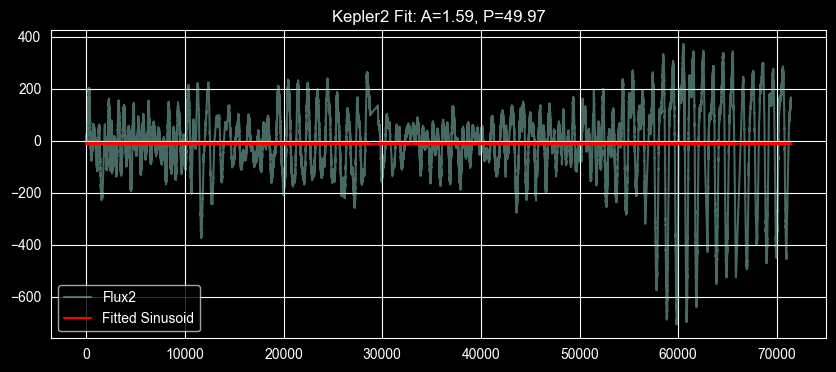

In [9]:
from scipy.optimize import curve_fit

def sinusoid(t, A, P, phi, offset):
    return A * np.sin(2 * np.pi * t / P + phi) + offset

# Use only finite values
finite = ~np.isnan(flux2)
t_fit = t2[finite]
f_fit = flux2[finite] - np.nanmedian(flux2)

# Initial guesses: A=10, P=50, phi=0, offset=0
popt, _ = curve_fit(sinusoid, t_fit, f_fit, p0=[10, 50, 0, 0])
A, P, phi, offset = popt

# Reconstruct fitted signal
fitted = sinusoid(t_fit, *popt)

plt.figure(figsize=(10, 4))
plt.plot(t_fit, f_fit, label='Flux2', alpha=0.5)
plt.plot(t_fit, fitted, label='Fitted Sinusoid', color='r')
plt.legend()
plt.title(f"Kepler2 Fit: A={A:.2f}, P={P:.2f}")
plt.grid(True)
plt.show()

## Using Gaussian Processes to simulate probable noise

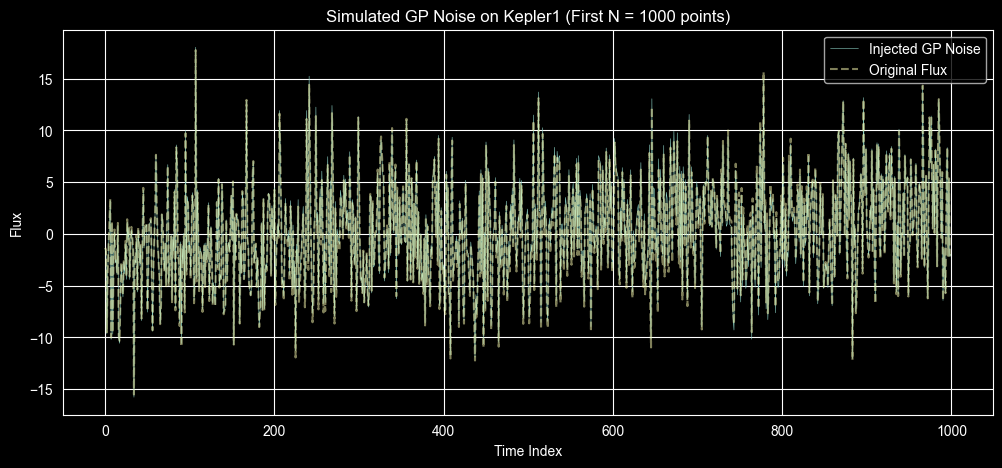

In [10]:
np.random.seed(442)

def man_ExpSquaredKernel(t1, t2=None, A=1.0, l=1.0):
    if t2 is None:
        t2 = t1
    T2, T1 = np.meshgrid(t2, t1)
    return A ** 2 * np.exp(-0.5 * (T1-T2)**2 / l**2)

N = 1000
t1_sub = t1[:N]
flux1_sub = flux1_interp[:N]

cov1_sub = man_ExpSquaredKernel(t1_sub, A = 0.5, l = 50.0)
gp_noise_sub1 = np.random.multivariate_normal(mean=np.zeros(N), cov=cov1_sub)

# Add GP noise
flux_gp_injected1 = flux1_sub + gp_noise_sub1

plt.figure(figsize=(12, 5))
plt.plot(t1_sub, flux_gp_injected1, label='Injected GP Noise', lw = 0.4)
plt.plot(t1_sub, flux1_sub, '--', label='Original Flux', alpha=0.5)
plt.xlabel("Time Index")
plt.ylabel("Flux")
plt.legend()
plt.title("Simulated GP Noise on Kepler1 (First N = 1000 points)")
plt.grid(True)
plt.show()

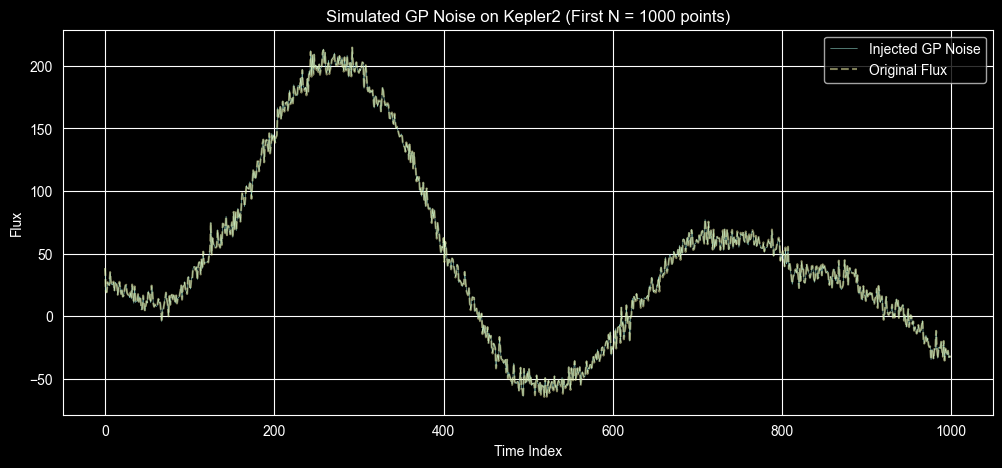

In [11]:
np.random.seed(442)

N = 1000
t2_sub = t2[:N]
flux2_sub = flux2_interp[:N]

cov2_sub = man_ExpSquaredKernel(t2_sub, A = 0.5, l = 50.0)
gp_noise_sub2 = np.random.multivariate_normal(mean=np.zeros(N), cov=cov2_sub)

# Add GP noise
flux_gp_injected2 = flux2_sub + gp_noise_sub2

plt.figure(figsize=(12, 5))
plt.plot(t2_sub, flux_gp_injected2, label='Injected GP Noise', lw = 0.4)
plt.plot(t2_sub, flux2_sub, '--', label='Original Flux', alpha=0.5)
plt.xlabel("Time Index")
plt.ylabel("Flux")
plt.legend()
plt.title("Simulated GP Noise on Kepler2 (First N = 1000 points)")
plt.grid(True)
plt.show()

## Modeling around Kepler datas using GPR

### Kepler 1 imputation

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from scipy.interpolate import interp1d
import IPython.display as display

# Step 1: Load flux data (Note: ensure path matches your environment)
flux1 = np.genfromtxt("datasets/Kepler1.dat", dtype=np.float32, missing_values="NA", filling_values=np.nan)

# Step 2: Create time index
t1 = np.arange(len(flux1))

# Step 3: Get observed (non-NaN) values ONLY
mask = ~np.isnan(flux1)
t1_valid = t1[mask]
y1_valid = flux1[mask]

# Step 3.5: Subsample the flux data before split to manage O(N^3) memory constraints
subset = 100
t1_sub = t1_valid[::subset]
y1_sub = y1_valid[::subset]

# Step 3.6: Randomized Train-Test Split (80% Train, 20% Test)

# --- 1. Setup Monte Carlo Cross-Validation ---
n_repetitions = 20
seeds = range(n_repetitions)

# Storage for GP metrics
gp_rmse_list, gp_mae_list, gp_r2_list = [], [], []
gp_1sigma_list, gp_2sigma_list, gp_std_list = [], [], []

# Storage for Baseline metrics
lin_rmse_list, lin_mae_list, lin_r2_list = [], [], []
cub_rmse_list, cub_mae_list, cub_r2_list = [], [], []

print(f"Running Monte Carlo Cross-Validation across {n_repetitions} seeds...")

kernel1 = 1.0 * RBF(length_scale=100.0) + WhiteKernel(noise_level=1.0)

for seed in seeds:
    # Randomized Split
    t1_train, t1_test, y1_train, y1_test = train_test_split(
        t1_sub, y1_sub, test_size=0.2, random_state=seed
    )

    # Sort arrays for clean interpolation
    sort_train = np.argsort(t1_train)
    t1_train, y1_train = t1_train[sort_train], y1_train[sort_train]
    sort_test = np.argsort(t1_test)
    t1_test, y1_test = t1_test[sort_test], y1_test[sort_test]

    X1_train, X1_test = t1_train.reshape(-1, 1), t1_test.reshape(-1, 1)

    # --- Fit & Evaluate GP ---
    gpr1 = GaussianProcessRegressor(kernel=kernel1, alpha=1e-2, normalize_y=True, random_state=seed)
    gpr1.fit(X1_train, y1_train)
    y1_pred, y1_std = gpr1.predict(X1_test, return_std=True)

    gp_rmse_list.append(np.sqrt(mean_squared_error(y1_test, y1_pred)))
    gp_mae_list.append(mean_absolute_error(y1_test, y1_pred))
    gp_r2_list.append(r2_score(y1_test, y1_pred))
    gp_std_list.append(np.mean(y1_std))

    # Uncertainty Coverage
    gp_1sigma_list.append(np.mean((y1_test >= y1_pred - y1_std) & (y1_test <= y1_pred + y1_std)))
    gp_2sigma_list.append(np.mean((y1_test >= y1_pred - 2*y1_std) & (y1_test <= y1_pred + 2*y1_std)))

    # --- Fit & Evaluate Baselines ---
    # Linear
    lin_interp = interp1d(t1_train, y1_train, kind='linear', fill_value='extrapolate')
    y_pred_lin = lin_interp(t1_test)
    lin_rmse_list.append(np.sqrt(mean_squared_error(y1_test, y_pred_lin)))
    lin_mae_list.append(mean_absolute_error(y1_test, y_pred_lin))
    lin_r2_list.append(r2_score(y1_test, y_pred_lin))

    # Cubic
    cub_interp = interp1d(t1_train, y1_train, kind='cubic', fill_value='extrapolate')
    y_pred_cub = cub_interp(t1_test)
    cub_rmse_list.append(np.sqrt(mean_squared_error(y1_test, y_pred_cub)))
    cub_mae_list.append(mean_absolute_error(y1_test, y_pred_cub))
    cub_r2_list.append(r2_score(y1_test, y_pred_cub))

print("Monte Carlo evaluation complete.")

Running Monte Carlo Cross-Validation across 20 seeds...
Monte Carlo evaluation complete.


In [33]:
# --- 1. Compute Aggregates ---
benchmark_data = {
    "Method": ["Linear Interpolation", "Cubic Spline", "Gaussian Process"],
    "RMSE Mean": [np.mean(lin_rmse_list), np.mean(cub_rmse_list), np.mean(gp_rmse_list)],
    "RMSE Std": [np.std(lin_rmse_list), np.std(cub_rmse_list), np.std(gp_rmse_list)],
    "MAE Mean": [np.mean(lin_mae_list), np.mean(cub_mae_list), np.mean(gp_mae_list)],
    "MAE Std": [np.std(lin_mae_list), np.std(cub_mae_list), np.std(gp_mae_list)],
    "R² Mean": [np.mean(lin_r2_list), np.mean(cub_r2_list), np.mean(gp_r2_list)],
    "R² Std": [np.std(lin_r2_list), np.std(cub_r2_list), np.std(gp_r2_list)]
}

benchmark_df = pd.DataFrame(benchmark_data)

print("--- Kepler 1 Benchmark Results (20 Seeds) ---")
display.display(benchmark_df.round(4))

# --- 2. Uncertainty Calibration Summary ---
print("\n--- GP Uncertainty Calibration Summary ---")
print(f"Average 1σ Coverage: {np.mean(gp_1sigma_list)*100:.2f}% ± {np.std(gp_1sigma_list)*100:.2f}% (Ideal: ~68%)")
print(f"Average 2σ Coverage: {np.mean(gp_2sigma_list)*100:.2f}% ± {np.std(gp_2sigma_list)*100:.2f}% (Ideal: ~95%)")

# --- 3. Best/Worst Case Analysis ---
best_seed_idx = np.argmin(gp_rmse_list)
worst_seed_idx = np.argmax(gp_rmse_list)
print("\n--- Sensitivity to Train-Test Split ---")
print(f"Best GP RMSE:  {gp_rmse_list[best_seed_idx]:.4f} (Seed {seeds[best_seed_idx]})")
print(f"Worst GP RMSE: {gp_rmse_list[worst_seed_idx]:.4f} (Seed {seeds[worst_seed_idx]})")

--- Kepler 1 Benchmark Results (20 Seeds) ---


,Method,RMSE Mean,RMSE Std,MAE Mean,MAE Std,R² Mean,R² Std
0,Linear Interpolation,6.2827,0.3437,5.1008,0.3127,-0.5733,0.1151
1,Cubic Spline,8.6941,1.1385,6.6883,0.5017,-2.0335,0.7128
2,Gaussian Process,5.0477,0.2525,4.1156,0.2176,-0.0136,0.0182



--- GP Uncertainty Calibration Summary ---
Average 1σ Coverage: 65.12% ± 4.24% (Ideal: ~68%)
Average 2σ Coverage: 96.07% ± 1.63% (Ideal: ~95%)

--- Sensitivity to Train-Test Split ---
Best GP RMSE:  4.6718 (Seed 11)
Worst GP RMSE: 5.5869 (Seed 7)


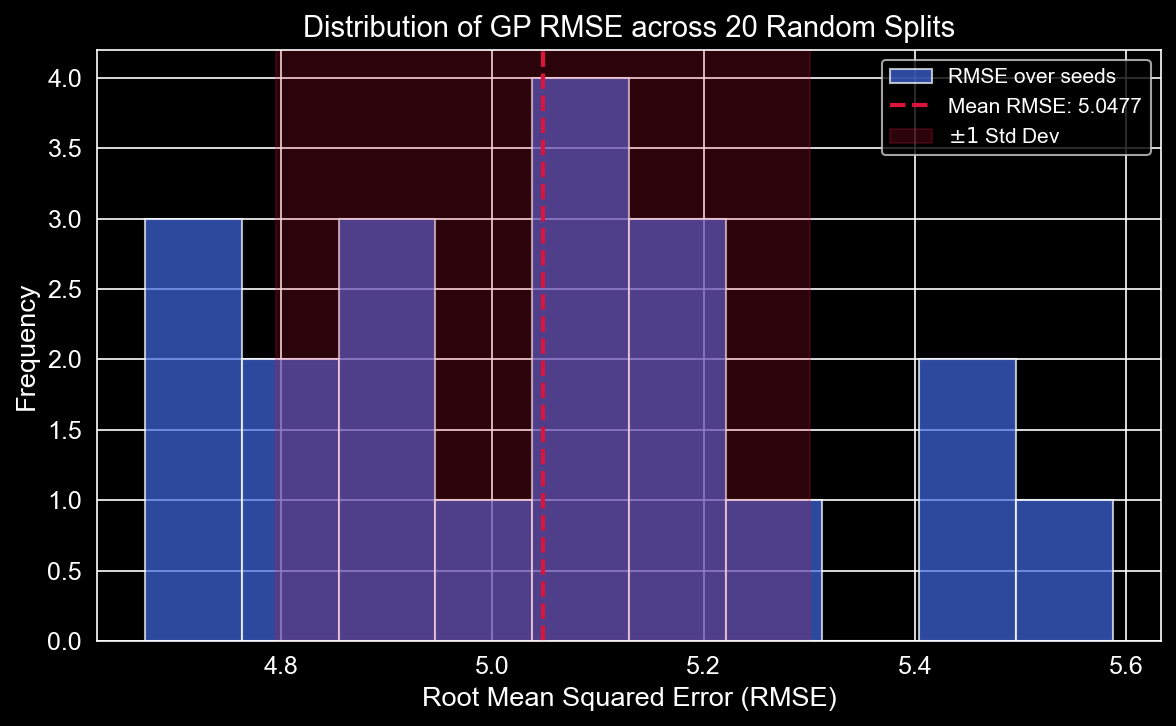

In [34]:
# --- Plot RMSE Distribution ---
plt.figure(figsize=(8, 5))
mean_rmse = np.mean(gp_rmse_list)
std_rmse = np.std(gp_rmse_list)

plt.hist(gp_rmse_list, bins=10, color='royalblue', edgecolor='white', alpha=0.7, label='RMSE over seeds')
plt.axvline(mean_rmse, color='crimson', linestyle='dashed', linewidth=2, label=f'Mean RMSE: {mean_rmse:.4f}')
plt.axvspan(mean_rmse - std_rmse, mean_rmse + std_rmse, color='crimson', alpha=0.2, label=r'$\pm 1$ Std Dev')

plt.title(f"Distribution of GP RMSE across {n_repetitions} Random Splits", fontsize=14)
plt.xlabel("Root Mean Squared Error (RMSE)")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.savefig("figures/kepler1_rmse_distribution.png", bbox_inches='tight')
plt.show()

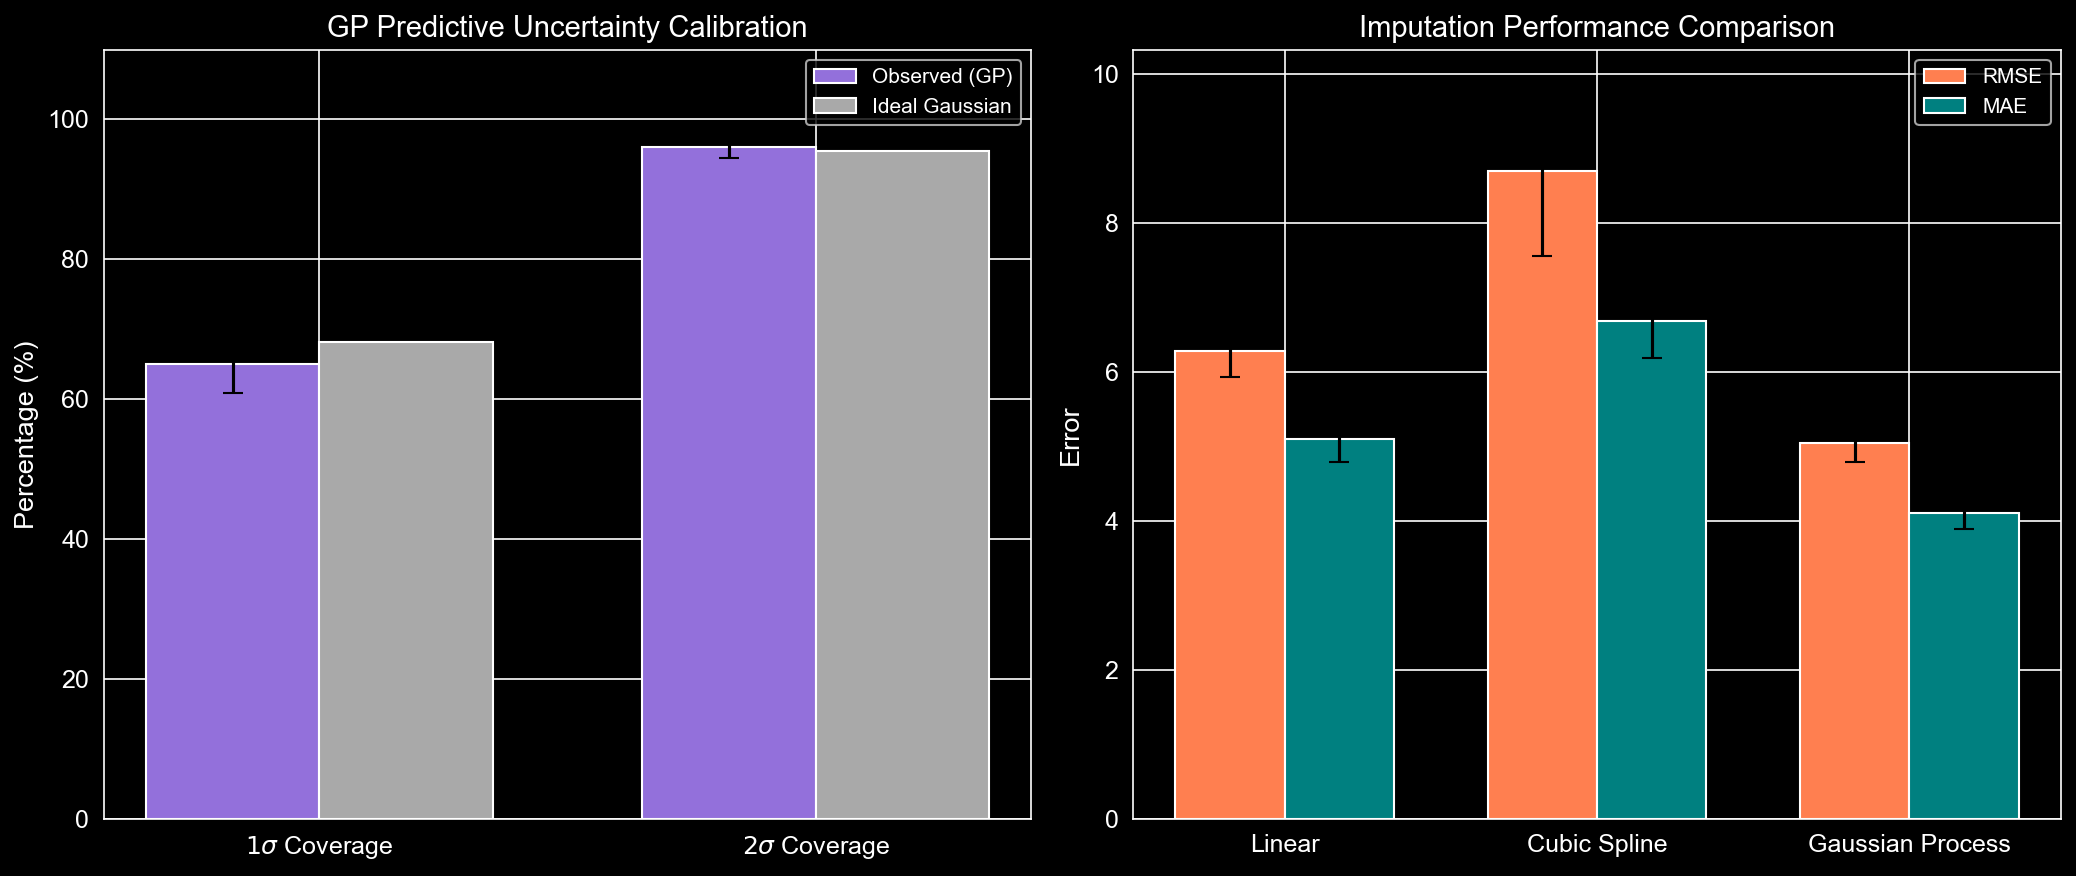

In [35]:
# --- Uncertainty Calibration Visualization ---
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Panel 1: Calibration
categories = [r'$1\sigma$ Coverage', r'$2\sigma$ Coverage']
observed_means = [np.mean(gp_1sigma_list) * 100, np.mean(gp_2sigma_list) * 100]
observed_stds = [np.std(gp_1sigma_list) * 100, np.std(gp_2sigma_list) * 100]
ideal_values = [68.27, 95.45]

x = np.arange(len(categories))
width = 0.35

axes[0].bar(x - width/2, observed_means, width, yerr=observed_stds, capsize=5, color='mediumpurple', label='Observed (GP)')
axes[0].bar(x + width/2, ideal_values, width, color='darkgray', label='Ideal Gaussian')
axes[0].set_xticks(x)
axes[0].set_xticklabels(categories)
axes[0].set_ylabel("Percentage (%)")
axes[0].set_title("GP Predictive Uncertainty Calibration")
axes[0].set_ylim(0, 110)
axes[0].legend()

# Panel 2: Benchmark Comparison
methods = ["Linear", "Cubic Spline", "Gaussian Process"]
rmse_means = [np.mean(lin_rmse_list), np.mean(cub_rmse_list), np.mean(gp_rmse_list)]
rmse_stds = [np.std(lin_rmse_list), np.std(cub_rmse_list), np.std(gp_rmse_list)]
mae_means = [np.mean(lin_mae_list), np.mean(cub_mae_list), np.mean(gp_mae_list)]
mae_stds = [np.std(lin_mae_list), np.std(cub_mae_list), np.std(gp_mae_list)]

x_methods = np.arange(len(methods))
axes[1].bar(x_methods - width/2, rmse_means, width, yerr=rmse_stds, capsize=5, color='coral', label='RMSE')
axes[1].bar(x_methods + width/2, mae_means, width, yerr=mae_stds, capsize=5, color='teal', label='MAE')
axes[1].set_xticks(x_methods)
axes[1].set_xticklabels(methods)
axes[1].set_ylabel("Error")
axes[1].set_title("Imputation Performance Comparison")
axes[1].legend()

plt.tight_layout()
plt.savefig("figures/kepler1_calibration_and_comparison.png", bbox_inches='tight')
plt.show()

Generating visualization for Representative Kepler 1 Seed: 16 (RMSE: 5.0506)


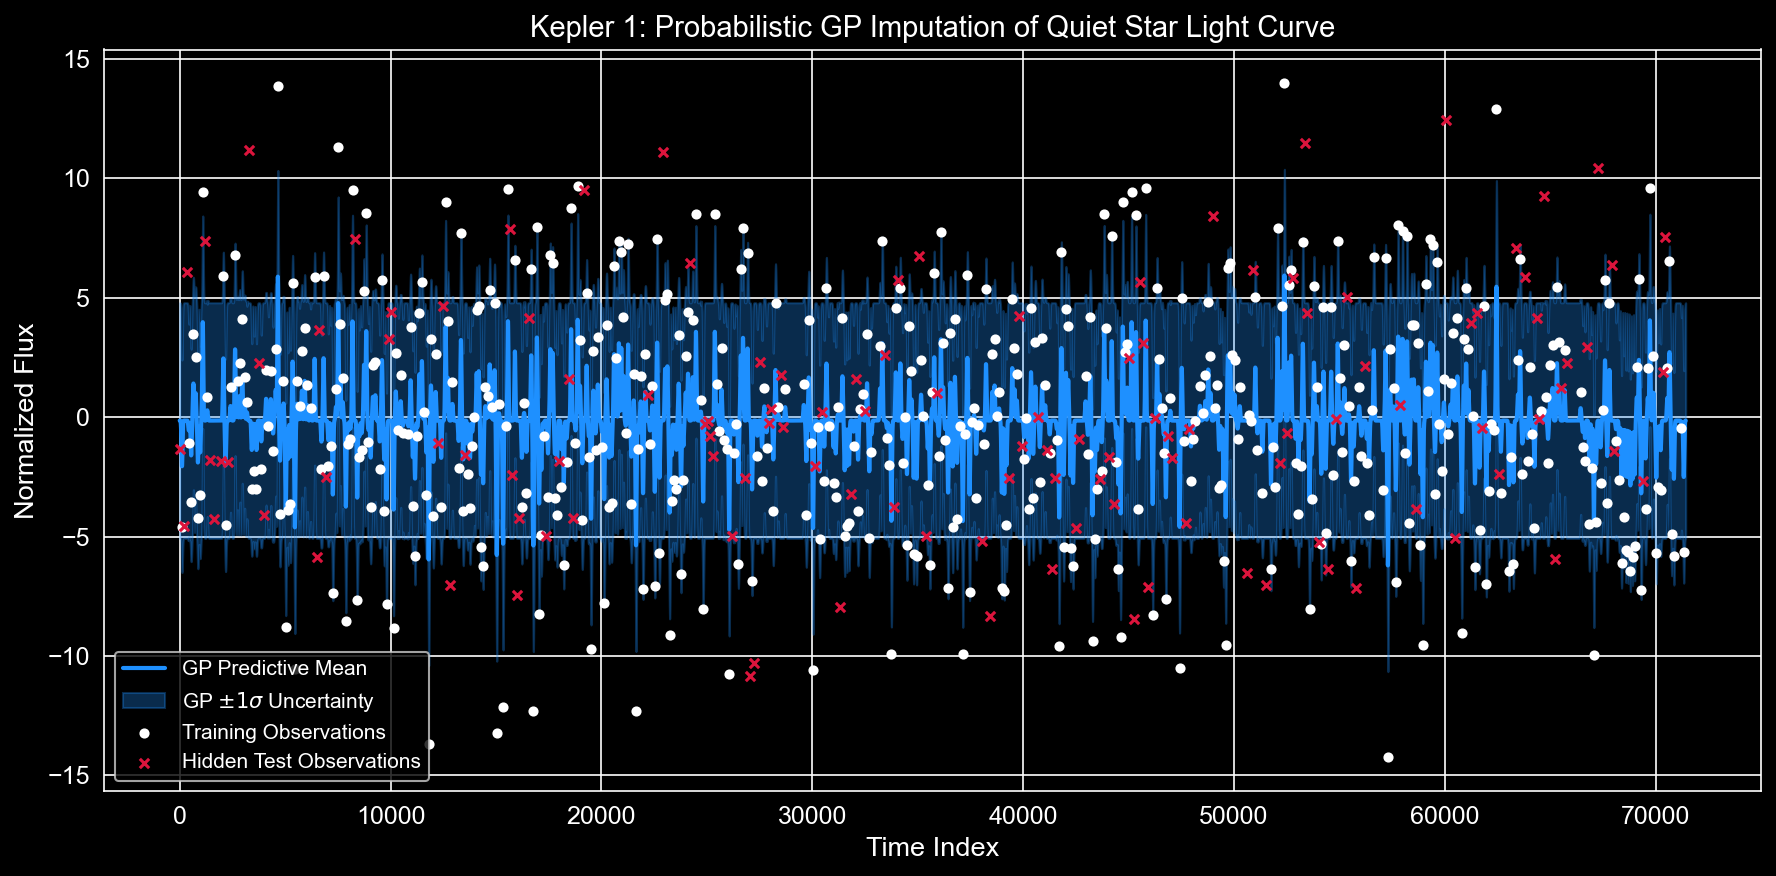

In [36]:
# --- Visualization of the Best GP Model Split for Kepler 1 ---

# Identify the representative seed closest to the mean RMSE
mean_rmse = np.mean(gp_rmse_list)
representative_idx = np.argmin(np.abs(np.array(gp_rmse_list) - mean_rmse))
representative_seed = seeds[representative_idx]

print(f"Generating visualization for Representative Kepler 1 Seed: {representative_seed} (RMSE: {gp_rmse_list[representative_idx]:.4f})")

# Step 2: Recreate the train/test split for that specific representative seed
t1_train_rep, t1_test_rep, y1_train_rep, y1_test_rep = train_test_split(
    t1_sub, y1_sub, test_size=0.2, random_state=representative_seed
)

X1_train_rep = t1_train_rep.reshape(-1, 1)

# Step 3: Retrain the GP model on the representative split
gpr1_rep = GaussianProcessRegressor(kernel=kernel1, alpha=1e-2, normalize_y=True, random_state=representative_seed)
gpr1_rep.fit(X1_train_rep, y1_train_rep)

# Step 4: Predict over the FULL original time range to generate the smooth background band
X1_all = t1.reshape(-1, 1)
y1_pred_all_rep, y1_std_all_rep = gpr1_rep.predict(X1_all, return_std=True)

# Publication-style Plotting
fig, ax = plt.subplots(figsize=(12, 6))
ax.plot(t1, y1_pred_all_rep, color='dodgerblue', label='GP Predictive Mean', lw=2)
ax.fill_between(t1, y1_pred_all_rep - y1_std_all_rep, y1_pred_all_rep + y1_std_all_rep,
                color='dodgerblue', alpha=0.3, label=r'GP $\pm 1\sigma$ Uncertainty')

ax.scatter(t1_train_rep, y1_train_rep, color='white', s=15, label='Training Observations', zorder=3)
ax.scatter(t1_test_rep, y1_test_rep, color='crimson', s=20, marker='x', label='Hidden Test Observations', zorder=4)

ax.set_title("Kepler 1: Probabilistic GP Imputation of Quiet Star Light Curve")
ax.set_xlabel("Time Index")
ax.set_ylabel("Normalized Flux")
ax.legend(loc='lower left')
plt.tight_layout()
plt.savefig("figures/kepler1_gp_imputation.png", bbox_inches='tight')
plt.show()

Running Randomized Block Masking Evaluation...


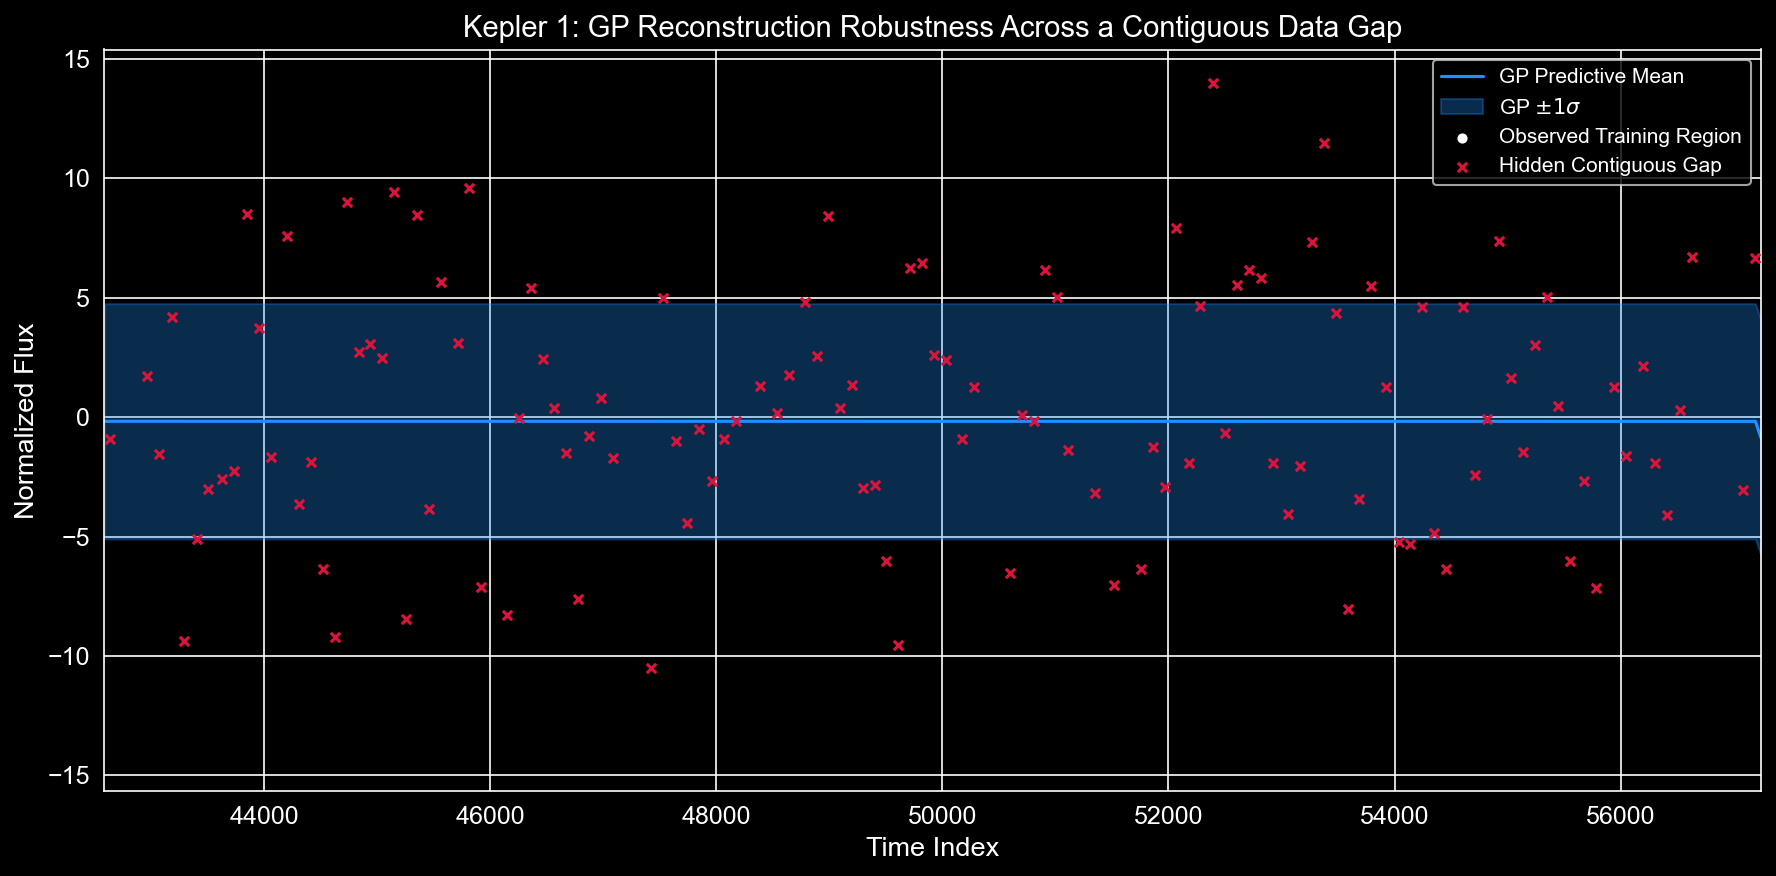

In [37]:
# --- RANDOMIZED BLOCK MASKING EXPERIMENT & VISUALIZATION ---
n_block_seeds = 20
block_size = int(len(t1_sub) * 0.2) # 20% continuous gap
max_start_idx = len(t1_sub) - block_size

gap_rmse_list = []
gap_predictions = []

print("Running Randomized Block Masking Evaluation...")

for seed in range(n_block_seeds):
    rng = np.random.RandomState(seed)
    start_idx = rng.randint(0, max_start_idx)
    end_idx = start_idx + block_size

    train_mask = np.ones(len(t1_sub), dtype=bool)
    train_mask[start_idx:end_idx] = False
    test_mask = ~train_mask

    t_train_gap, y_train_gap = t1_sub[train_mask], y1_sub[train_mask]
    t_test_gap, y_test_gap = t1_sub[test_mask], y1_sub[test_mask]

    gpr_gap = GaussianProcessRegressor(kernel=kernel1, alpha=1e-2, normalize_y=True, random_state=seed)
    gpr_gap.fit(t_train_gap.reshape(-1, 1), y_train_gap)

    y_pred_gap, y_std_gap = gpr_gap.predict(t_test_gap.reshape(-1, 1), return_std=True)
    gap_rmse_list.append(np.sqrt(mean_squared_error(y_test_gap, y_pred_gap)))

    gap_predictions.append({
        't_train': t_train_gap, 'y_train': y_train_gap,
        't_test': t_test_gap, 'y_test': y_test_gap,
        'gpr': gpr_gap
    })

# Plot Representative Gap Reconstruction
rep_gap_idx = np.argmin(np.abs(np.array(gap_rmse_list) - np.mean(gap_rmse_list)))
rep_gap = gap_predictions[rep_gap_idx]

# Predict smoothly over the specific gap area
t_plot_gap = np.linspace(rep_gap['t_test'].min() - 50, rep_gap['t_test'].max() + 50, 300)
y_plot_pred, y_plot_std = rep_gap['gpr'].predict(t_plot_gap.reshape(-1, 1), return_std=True)

plt.figure(figsize=(12, 6))
plt.plot(t_plot_gap, y_plot_pred, color='dodgerblue', label='GP Predictive Mean')
plt.fill_between(t_plot_gap, y_plot_pred - y_plot_std, y_plot_pred + y_plot_std, color='dodgerblue', alpha=0.3, label=r'GP $\pm 1\sigma$')
plt.scatter(rep_gap['t_train'], rep_gap['y_train'], color='white', s=15, label='Observed Training Region', zorder=3)
plt.scatter(rep_gap['t_test'], rep_gap['y_test'], color='crimson', s=20, marker='x', label='Hidden Contiguous Gap', zorder=4)

plt.xlim(t_plot_gap.min(), t_plot_gap.max())
plt.title("Kepler 1: GP Reconstruction Robustness Across a Contiguous Data Gap")
plt.xlabel("Time Index")
plt.ylabel("Normalized Flux")
plt.legend()
plt.tight_layout()
plt.savefig("figures/kepler1_block_gap_reconstruction.png", bbox_inches='tight')
plt.show()

### Modeling Structured Periodicity with `Kepler2.dat` using _Quasi-Periodic_ Kernel

> Mathematically, the `Quasi-Periodic Kernel` can be written as: <br>
$$
\gamma (t_i, t_j) = H_\mathrm{amp}^2  \exp{ \left \{-\frac{\sin^2{[\pi(t_i - t_j)/ P_\mathrm{rot}]}}{2 O_\mathrm{amp} ^2} - \frac{(t_i-t_j)^2}{2 P_\mathrm{dec}^2} \right \} }
$$

where, <br>
* $P_{\text{rot}}$ is the rotational period of the star
* $O_{\text{amp}}$ is the coherence scale
* $P_{\text{dec}}$ is the decay time scale of the active regions
* $H_{\text{amp}}$ is the amplitude of the kernel

In [39]:
from sklearn.gaussian_process.kernels import ExpSineSquared, ConstantKernel, RBF, WhiteKernel

# --- Kepler 2: Standard vs Quasi-Periodic Evaluation ---
# Step 1: Load and isolate valid data
flux2 = np.genfromtxt("datasets/Kepler2.dat", dtype=np.float32, missing_values="NA", filling_values=np.nan)
t2 = np.arange(len(flux2))

mask2 = ~np.isnan(flux2)
t2_valid = t2[mask2]
y2_valid = flux2[mask2]

# Subsample due to memory limitations
subset2 = 50
t2_sub = t2_valid[::subset2]
y2_sub = y2_valid[::subset2]

n_k2_seeds = 20

rbf_rmse_list, rbf_mae_list = [], []
qp_rmse_list, qp_mae_list = [], []

rbf_kernel2 = 1.0 * RBF(length_scale=100.0) + WhiteKernel(noise_level=1.0)
qp_kernel2 = (
    ConstantKernel(1.0, (1e-3, 1e3))
    * ExpSineSquared(
        length_scale=10.0,
        periodicity=150.0,
        length_scale_bounds=(1e-2, 1e4),
        periodicity_bounds=(10.0, 1e4)
    )
    * RBF(
        length_scale=200.0,
        length_scale_bounds=(1e-2, 1e5)
    )
    + WhiteKernel(
        noise_level=1.0,
        noise_level_bounds=(1e-6, 1e2)
    )
)

print(f"Evaluating kernels on Kepler 2 across {n_k2_seeds} seeds...")

for seed in range(n_k2_seeds):
    t2_train, t2_test, y2_train, y2_test = train_test_split(t2_sub, y2_sub, test_size=0.2, random_state=seed)
    X2_train, X2_test = t2_train.reshape(-1, 1), t2_test.reshape(-1, 1)

    # RBF Baseline
    gpr2_rbf = GaussianProcessRegressor(kernel=rbf_kernel2, alpha=1e-2, normalize_y=True, random_state=seed)
    gpr2_rbf.fit(X2_train, y2_train)
    y_pred_rbf = gpr2_rbf.predict(X2_test)

    rbf_rmse_list.append(np.sqrt(mean_squared_error(y2_test, y_pred_rbf)))
    rbf_mae_list.append(mean_absolute_error(y2_test, y_pred_rbf))

    # Quasi-Periodic Target
    gpr2_qp = GaussianProcessRegressor(kernel=qp_kernel2, alpha=1e-2, normalize_y=True, random_state=seed)
    gpr2_qp.fit(X2_train, y2_train)
    y_pred_qp = gpr2_qp.predict(X2_test)

    qp_rmse_list.append(np.sqrt(mean_squared_error(y2_test, y_pred_qp)))
    qp_mae_list.append(mean_absolute_error(y2_test, y_pred_qp))

# --- Kepler 2 Summary Table ---
k2_benchmark_data = {
    "Kernel Method": ["RBF (Standard)", "Quasi-Periodic"],
    "RMSE Mean": [np.mean(rbf_rmse_list), np.mean(qp_rmse_list)],
    "RMSE Std": [np.std(rbf_rmse_list), np.std(qp_rmse_list)],
    "MAE Mean": [np.mean(rbf_mae_list), np.mean(qp_mae_list)],
    "MAE Std": [np.std(rbf_mae_list), np.std(qp_mae_list)]
}

k2_benchmark_df = pd.DataFrame(k2_benchmark_data)
print("\n--- Kepler 2 Kernel Robustness Comparison ---")
display.display(k2_benchmark_df.round(4))

Evaluating kernels on Kepler 2 across 20 seeds...


/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1


--- Kepler 2 Kernel Robustness Comparison ---


/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


,Kernel Method,RMSE Mean,RMSE Std,MAE Mean,MAE Std
0,RBF (Standard),36.5371,9.0953,16.7843,2.1005
1,Quasi-Periodic,36.5366,9.0955,16.7836,2.1005


### --- KEPLER 2: ADVANCED VISUALIZATIONS & DIAGNOSTICS ---


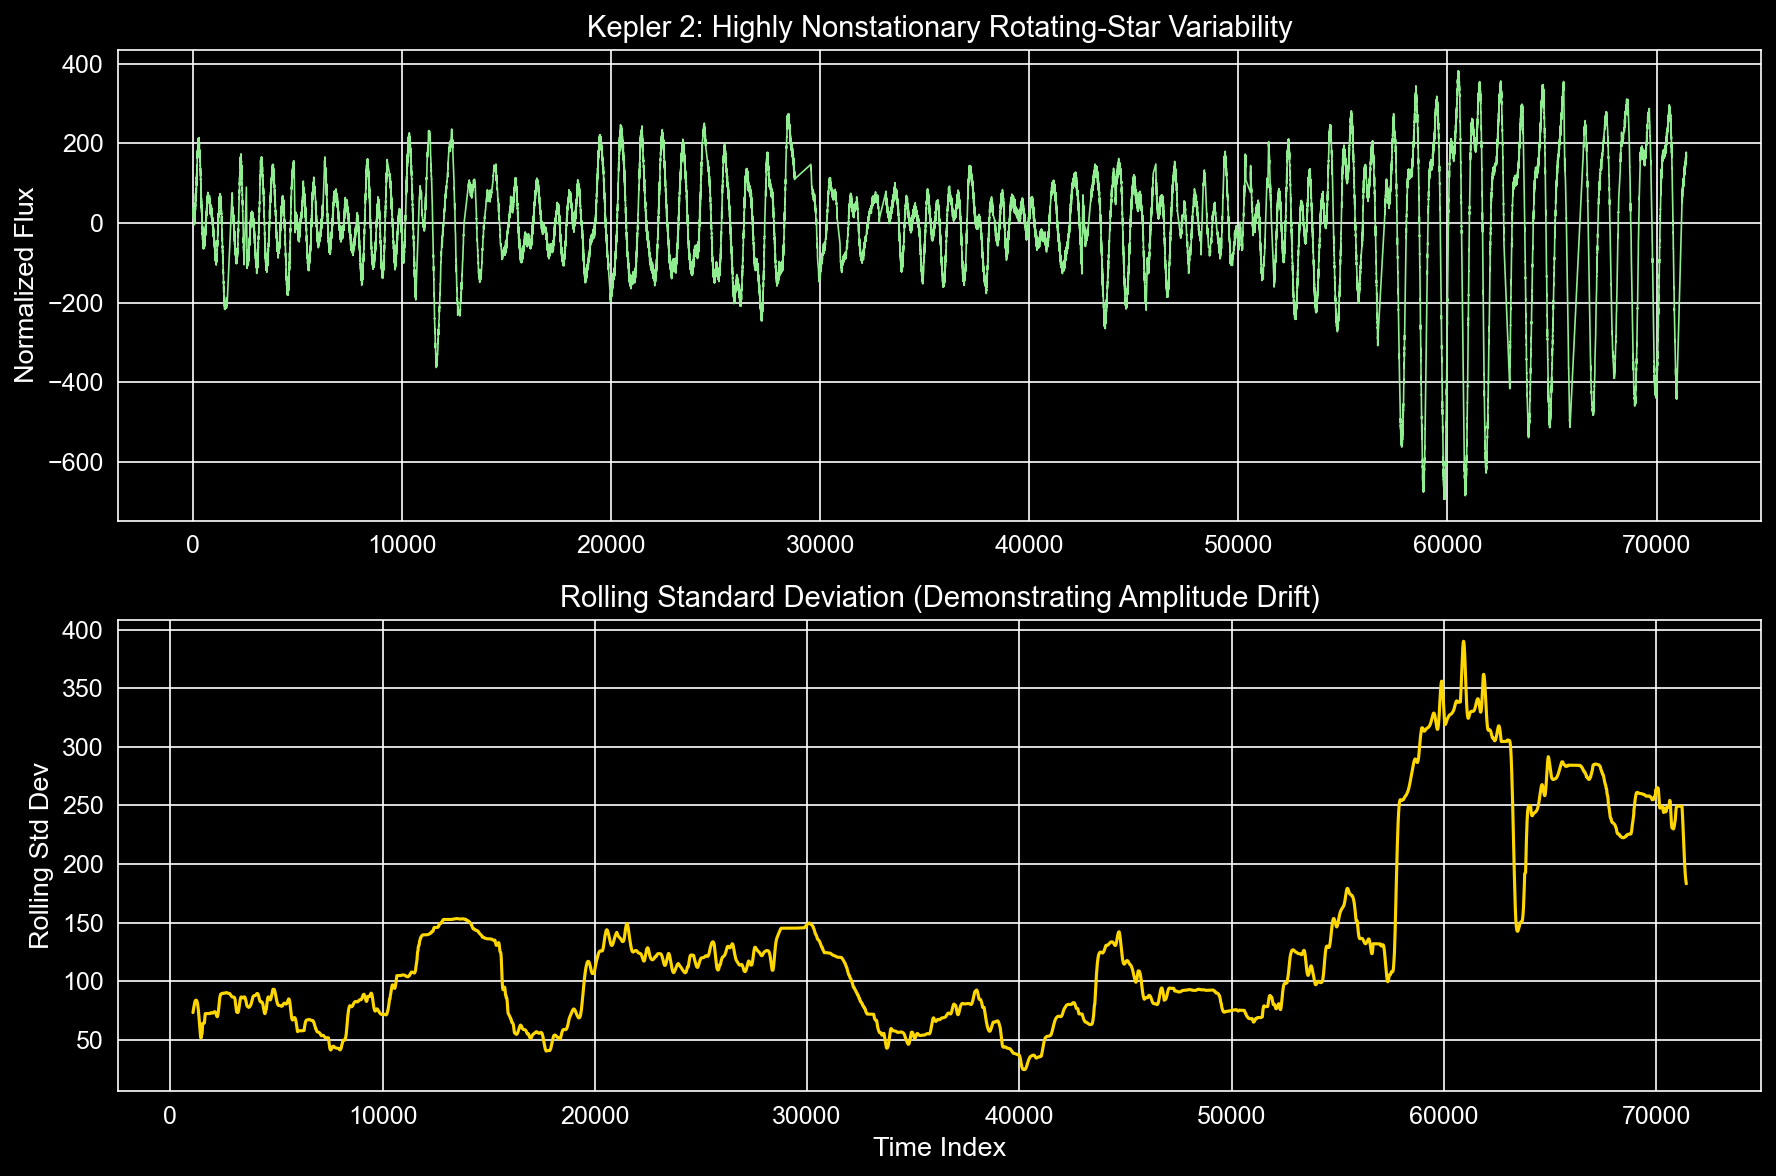

In [40]:
# 1. Nonstationarity Visualization
plt.figure(figsize=(12, 8))
plt.subplot(2, 1, 1)
plt.plot(t2_valid, y2_valid, color='lightgreen', lw=0.8)
plt.title("Kepler 2: Highly Nonstationary Rotating-Star Variability")
plt.ylabel("Normalized Flux")

plt.subplot(2, 1, 2)
rolling_std = pd.Series(y2_valid).rolling(window=1000).std()
plt.plot(t2_valid, rolling_std, color='gold', lw=1.5)
plt.title("Rolling Standard Deviation (Demonstrating Amplitude Drift)")
plt.xlabel("Time Index")
plt.ylabel("Rolling Std Dev")
plt.tight_layout()
plt.savefig("figures/kepler2_nonstationarity.png", bbox_inches='tight')
plt.show()

/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k1__k2__length_scale is close to the specified upper bound 10000.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/Users/shyambanerjee/PycharmProjects/noisy_light_curve_simulation/.venv/lib/python3.9/site-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-06. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


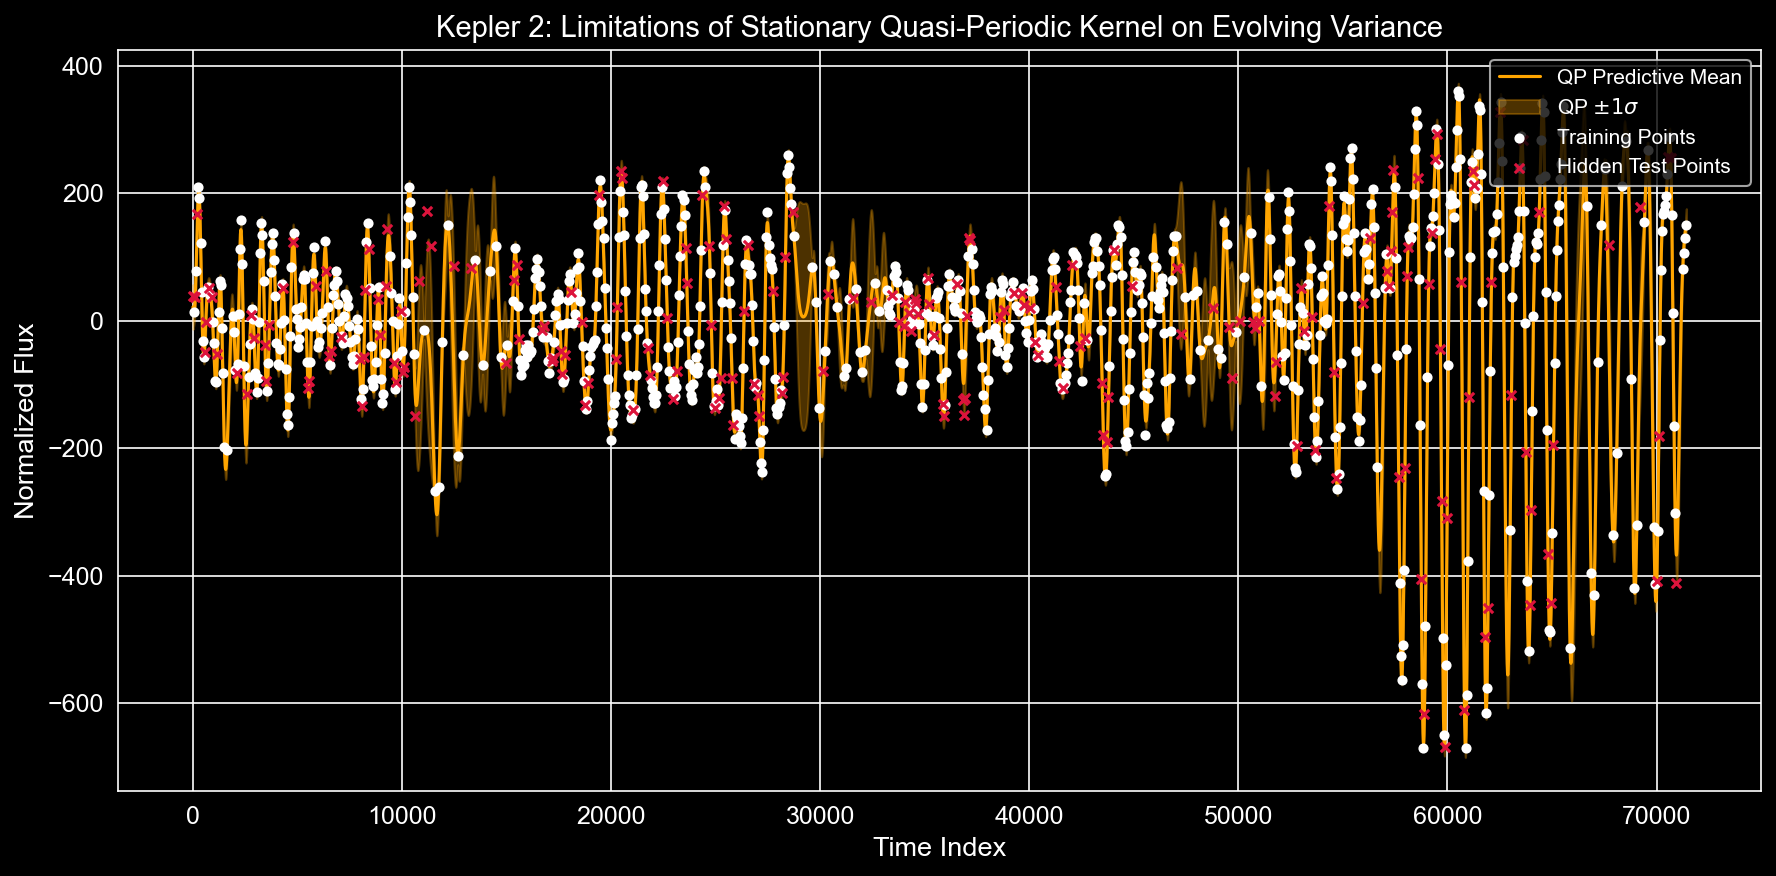

In [41]:
# 2. Representative QP Kernel Limitation Visualization
rep_qp_idx = np.argmin(np.abs(np.array(qp_rmse_list) - np.mean(qp_rmse_list)))
t2_train_rep, t2_test_rep, y2_train_rep, y2_test_rep = train_test_split(t2_sub, y2_sub, test_size=0.2, random_state=rep_qp_idx)

gpr2_qp_rep = GaussianProcessRegressor(kernel=qp_kernel2, alpha=1e-2, normalize_y=True, random_state=rep_qp_idx)
gpr2_qp_rep.fit(t2_train_rep.reshape(-1, 1), y2_train_rep)
y2_pred_all_qp, y2_std_all_qp = gpr2_qp_rep.predict(t2.reshape(-1, 1), return_std=True)

plt.figure(figsize=(12, 6))
plt.plot(t2, y2_pred_all_qp, color='orange', lw=1.5, label='QP Predictive Mean')
plt.fill_between(t2, y2_pred_all_qp - y2_std_all_qp, y2_pred_all_qp + y2_std_all_qp, color='orange', alpha=0.3, label=r'QP $\pm 1\sigma$')
plt.scatter(t2_train_rep, y2_train_rep, color='white', s=15, label='Training Points', zorder=3)
plt.scatter(t2_test_rep, y2_test_rep, color='crimson', s=20, marker='x', label='Hidden Test Points', zorder=4)

plt.title("Kepler 2: Limitations of Stationary Quasi-Periodic Kernel on Evolving Variance")
plt.xlabel("Time Index")
plt.ylabel("Normalized Flux")
plt.legend(loc='upper right')
plt.tight_layout()
plt.savefig("figures/kepler2_qp_limitation.png", bbox_inches='tight')
plt.show()

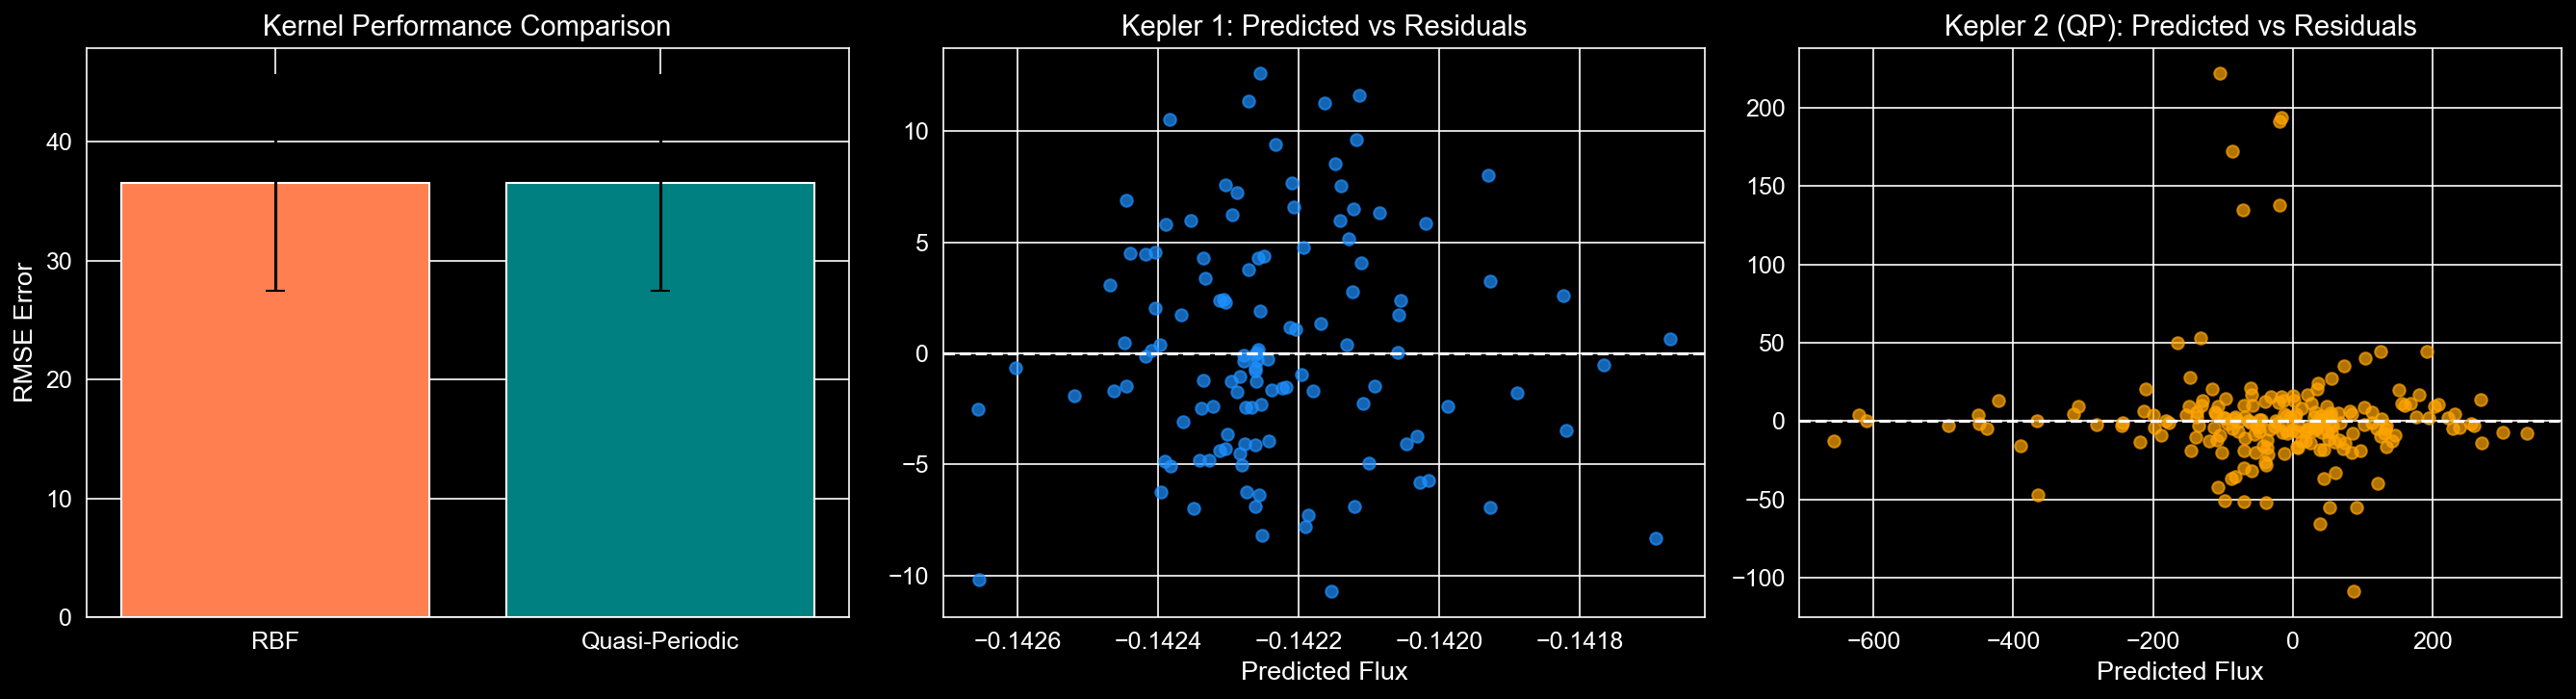

In [42]:
# 3. Kernel Comparison & Residual Diagnostics
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Kernel Comparison
kernels = ["RBF", "Quasi-Periodic"]
rmse_means_k2 = [np.mean(rbf_rmse_list), np.mean(qp_rmse_list)]
rmse_stds_k2 = [np.std(rbf_rmse_list), np.std(qp_rmse_list)]
axes[0].bar(kernels, rmse_means_k2, yerr=rmse_stds_k2, capsize=5, color=['coral', 'teal'])
axes[0].set_ylabel("RMSE Error")
axes[0].set_title("Kernel Performance Comparison")

# Kepler 1 Residuals (Using rep model from earlier)
y1_test_pred = gpr1_rep.predict(t1_test_rep.reshape(-1, 1))
res1 = y1_test_rep - y1_test_pred
axes[1].scatter(y1_test_pred, res1, color='dodgerblue', alpha=0.7)
axes[1].axhline(0, color='white', linestyle='--')
axes[1].set_title("Kepler 1: Predicted vs Residuals")
axes[1].set_xlabel("Predicted Flux")

# Kepler 2 QP Residuals
y2_test_pred = gpr2_qp_rep.predict(t2_test_rep.reshape(-1, 1))
res2 = y2_test_rep - y2_test_pred
axes[2].scatter(y2_test_pred, res2, color='orange', alpha=0.7)
axes[2].axhline(0, color='white', linestyle='--')
axes[2].set_title("Kepler 2 (QP): Predicted vs Residuals")
axes[2].set_xlabel("Predicted Flux")

plt.tight_layout()
plt.savefig("figures/kepler_diagnostics_and_comparison.png", bbox_inches='tight')
plt.show()